In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import random

# TEKTRONIK

In [16]:
# Load the dataset
file_name = "data/T0016ALL.CSV"
# data = pd.read_csv(file_name)

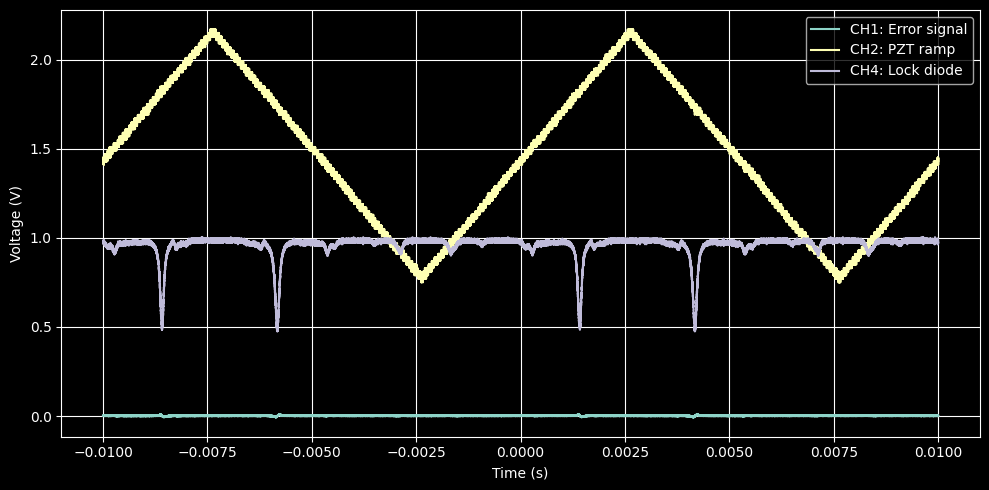

In [17]:
# Raw display of the channel
# find the line where the actual CSV starts
with open(file_name) as f:
    for i, line in enumerate(f):
        if line.startswith("TIME"):
            header_line = i
            break

# load the numeric data
data = np.loadtxt(file_name, delimiter=",", skiprows=header_line + 1)

# columns
t = data[:,0]
ch1 = data[:,1]
ch2 = data[:,3]
ch4 = data[:,5]

# plot
plt.figure(figsize=(10,5))
plt.plot(t, ch1, label="CH1: Error signal")
plt.plot(t, ch2, label="CH2: PZT ramp")
plt.plot(t, ch4, label="CH4: Lock diode")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Found 5 linear windows.


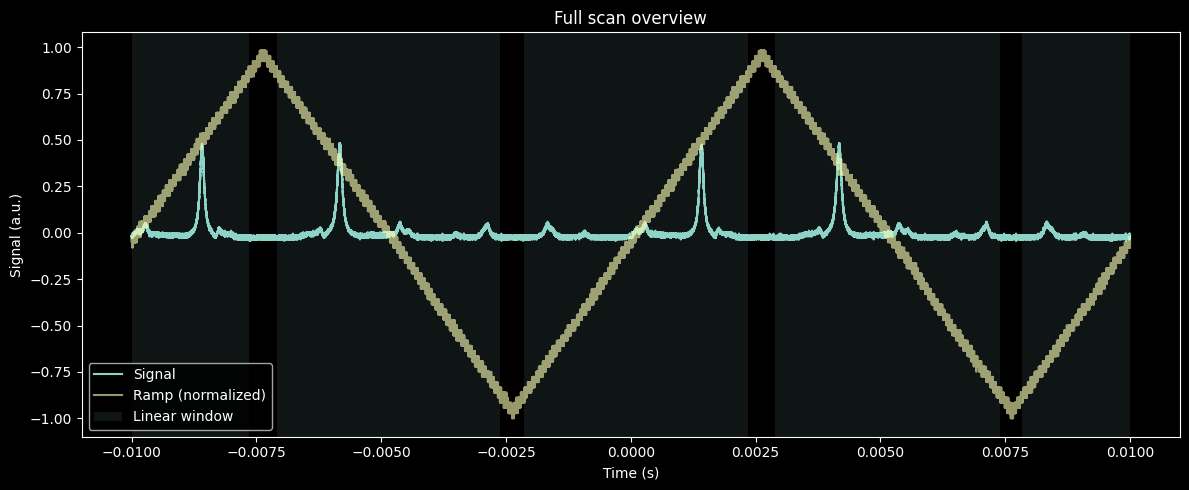

ZeroDivisionError: division by zero

In [20]:
# Constants
lambda0 = 780e-9  # m
c = 3e8  # m/s
L = 500e-3  # m cavity length

FSR = c / L  # Free Spectral Range in Hz

# Load signal data
#data_signal = np.loadtxt(
#    signal_file,
#    delimiter=",",
#    skiprows=16,
#    usecols=(0, 1)
#)

#time = data_signal[:, 0]
#signal = - data_signal[:, 1]

# Load ramp data
#data_ramp = np.loadtxt(
#    ramp_file,
#    delimiter=",",
#    skiprows=16,
#    usecols=(0, 1)
#)

#ramp = data_ramp[:, 1]

data = np.loadtxt(
    file_name,
    delimiter=",",
    skiprows=16,
    usecols=(0, 3, 5)
)

time = data[:,0]
ramp = data[:,1]      # CH2
signal = -data[:,2]   # CH4 (photodiode)

time = data[:, 0]
ramp = data[:, 1]      # CH2
signal = -data[:, 2]   # CH3 (keep minus if needed)

# Remove DC offset from signal
signal = signal - np.mean(signal)
ramp = ramp - np.mean(ramp)

# ----------------------------
# Define Lorentzian function
# ----------------------------
def lorentzian(x, A, x0, gamma, C):
    """
    Lorentzian function
    :param x:
    :param A:
    :param x0:
    :param gamma:
    :param C:
    :return:
    """
    return A * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2) + C

# ----------------------------
# Find linear ramp windows
# ----------------------------
max_ramp = np.max(ramp)
min_ramp = np.min(ramp)

threshold_low = min_ramp + 0.05 * (max_ramp - min_ramp)
threshold_high = max_ramp - 0.05 * (max_ramp - min_ramp)
linear_mask = (ramp > threshold_low) & (ramp < threshold_high)

segments = []
min_segment_length = 1000  # points
in_segment = False

for i, val in enumerate(linear_mask):
    if val and not in_segment:
        start_idx = i
        in_segment = True
    elif (not val or i == len(linear_mask)-1) and in_segment:
        end_idx = i
        in_segment = False
        if end_idx - start_idx >= min_segment_length:
            segments.append((start_idx, end_idx))

print(f"Found {len(segments)} linear windows.")

# Quick figure plot
plt.figure(figsize=(12, 5))

# Normalize ramp for visibility
ramp_norm = ramp / np.max(np.abs(ramp))

plt.plot(time, signal, label='Signal')
plt.plot(time, ramp_norm, label='Ramp (normalized)', alpha=0.6)

# Plot linear windows
for i, (start_idx, end_idx) in enumerate(segments):
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.1,
                label='Linear window' if i == 0 else None)

plt.xlabel("Time (s)")
plt.ylabel("Signal (a.u.)")
plt.title("Full scan overview")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Find peak within the ramp windows
# ----------------------------
# peak_indices = []
peak_fits = []
N = 1000  # window half-width for fitting
for window_id, (start_idx, end_idx) in enumerate(segments):
    segment_signal = signal[start_idx:end_idx]
    segment_time = time[start_idx:end_idx]

    peaks, _ = find_peaks(segment_signal, height=1.0, distance=1000)
    if len(peaks) < 2:
        continue

    # Frequency calibration from adjacent peaks
    dt_peaks = np.diff(segment_time[peaks])
    time_per_FSR = np.mean(dt_peaks)  # seconds per FSR
    Hz_per_sec = FSR / time_per_FSR

    for peak in peaks:
        if peak - N < 0 or peak + N >= len(segment_signal):
            continue

        xdata = segment_time[peak - N:peak + N]
        ydata = segment_signal[peak - N:peak + N]

        # Initial guess for Lorentzian parameters (we fit using frequency units for horizontal axis)
        A_guess = np.max(ydata) - np.min(ydata)
        x0_guess = segment_time[peak]
        gamma_guess = 1e6 / Hz_per_sec  # initial guess for FWHM in seconds
        C_guess = np.min(ydata)
        p0 = [A_guess, x0_guess, gamma_guess, C_guess]
        try:
            popt, pcov = curve_fit(
                lorentzian,
                xdata,
                ydata,
                p0=p0
            )

            # Extract fitted parameters
            A_fit, x0_fit, gamma_fit, C_fit = popt

            # Convert gamma from time to frequency units
            gamma_freq = gamma_fit * Hz_per_sec  # FWHM in Hz
            finesse = FSR / gamma_freq

            peak_fits.append({
                'A': A_fit,
                'x0': x0_fit,
                'gamma_time': gamma_fit,
                'gamma_freq': gamma_freq,
                'finesse': finesse,
                'C': C_fit,
                'window_id': window_id,
                'window_start': start_idx,
                'window_end': end_idx,
                'time_per_FSR': time_per_FSR
            })
        except RuntimeError:
            print("Error - curve_fit failed")
            continue

# ----------------------------
# Plot results (fits and data)
# ----------------------------
import math

num_peaks = len(peak_fits)
# --- Dynamic grid (near square layout) ---
cols = int(np.ceil(np.sqrt(num_peaks)))
rows = int(np.ceil(num_peaks / cols))

plt.figure(figsize=(4*cols, 3.5*rows))

for i, pf in enumerate(peak_fits):
    A = pf['A']
    x0 = pf['x0']
    gamma_time = pf['gamma_time']
    gamma_freq = pf['gamma_freq']
    finesse = pf['finesse']
    C = pf['C']

    # Generate fit data
    t_fit = np.linspace(x0 - 5*gamma_time, x0 + 5*gamma_time, 1000)
    y_fit = lorentzian(t_fit, A, x0, gamma_time, C)

    # Convert time axis to frequency axis for plotting
    time_per_FSR = pf['time_per_FSR']
    Hz_per_sec = FSR / time_per_FSR

    freq_fit = (t_fit - x0) * Hz_per_sec / 1e6
    freq_data = (time - x0) * Hz_per_sec / 1e6

    plt.subplot(rows, cols, i+1)
    plt.plot(freq_data, signal, label='Data', alpha=0.5)
    plt.plot(freq_fit, y_fit, label='Lorentzian Fit', color='red')

    # plt.title(f'Peak {i+1}: FWHM = {gamma_freq/1e6:.2f} MHz')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Signal (a.u.)')
    plt.xlim(freq_fit[0], freq_fit[-1])
    window_id = pf['window_id']

    plt.legend(
    title=f'Peak {i+1} (W{window_id}):\n'
          f'FWHM = {gamma_freq/1e6:.2f} MHz\n'
          f'F = {finesse:.1f}'
          )
plt.tight_layout()
plt.show()